In [6]:
from utils import read_ooc
from utils.helpers.plotting_helper import set_plotting_defaults

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.interpolate as interp

set_plotting_defaults()

In [3]:
oocs = read_ooc("dft.csv", material="znpc")

In [42]:
energyies = [250, 282, 283.7, 284, 285, 300]

# Plot the OOCS over this range

oocs_sliced = oocs[
    (oocs["energy"] >= 240) & (oocs["energy"] <= 320)
]
oocs_sliced.describe()

,energy,n_xx,n_zz,n_ixx,n_izz
count,3721.000000,3721.000000,3721.000000,3721.000000,3721.000000
mean,291.660054,0.000804,0.000838,0.000781,0.001697
std,13.163660,0.000680,0.001392,0.000695,0.001553
min,240.686500,-0.000653,-0.003005,0.000169,0.000172
25%,284.175000,0.000310,0.000612,0.000173,0.000936
50%,287.142500,0.000734,0.001386,0.000550,0.001012
75%,301.420000,0.001402,0.001581,0.001258,0.002360
max,320.000000,0.002137,0.003271,0.002187,0.006452


In [68]:
def slice_range(df, col, center, bounds, min_length=3):
    """
    Slice a dataframe to a range with a min length.

    Finds the row of the center value and then computes
    the range from there to ensure the slice contains at least
    the min_side number of points. By default the range is includes
    a row below and a row above the center.
    """
    from math import floor, ceil
    # Find the index of the row whose value in 'col' is closest to 'center'
    center_row = (df[col] - center).abs().idxmin()
    mask = (df[col] >= center - bounds) & (df[col] <= center + bounds)
    if sum(mask) < min_length:
        return df[center_row-floor(min_length/2):center_row+ceil(min_length/2)]
    return df[mask]


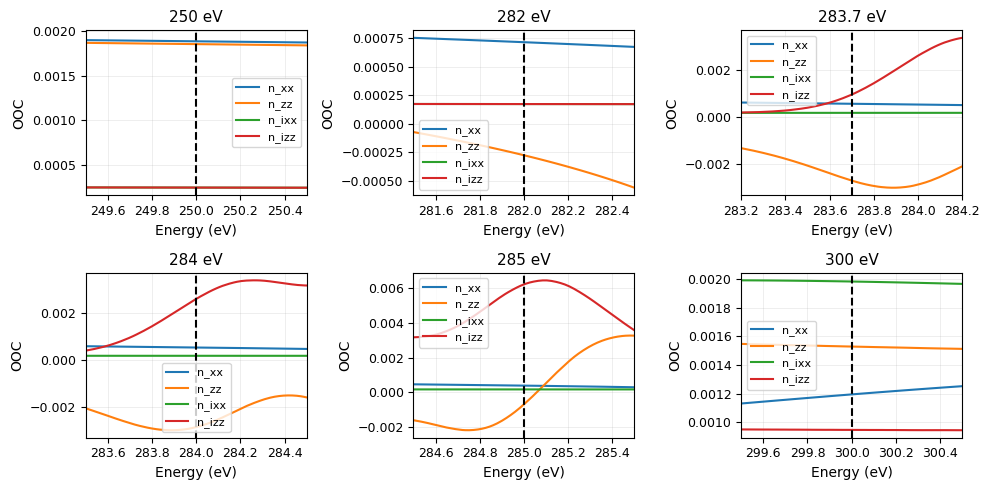

In [69]:
fig, _ax = plt.subplots(nrows=2, ncols=3, figsize=(10, 5))
ax = _ax.flatten()
for i, energy in enumerate(energyies):
    _masked = slice_range(oocs, "energy", energy, .5)
    _masked.plot(x="energy", ax=ax[i])
    ax[i].set_title(f"{energy} eV")
    ax[i].set_xlabel("Energy (eV)")
    ax[i].set_ylabel("OOC")
    ax[i].set_xlim(energy - 0.5, energy + 0.5)

    # add a vertical line at the energy
    ax[i].axvline(energy, color="k", linestyle="--")

plt.tight_layout()

In [72]:
from time import perf_counter

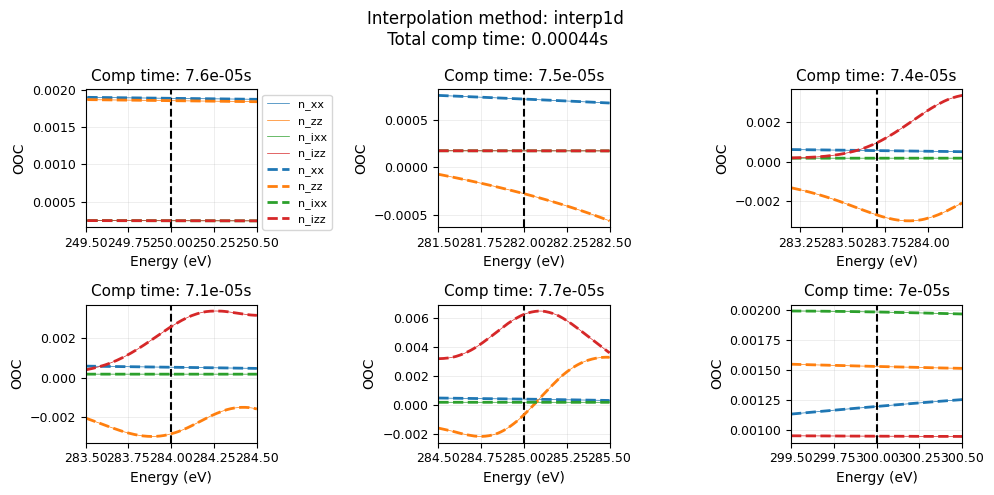

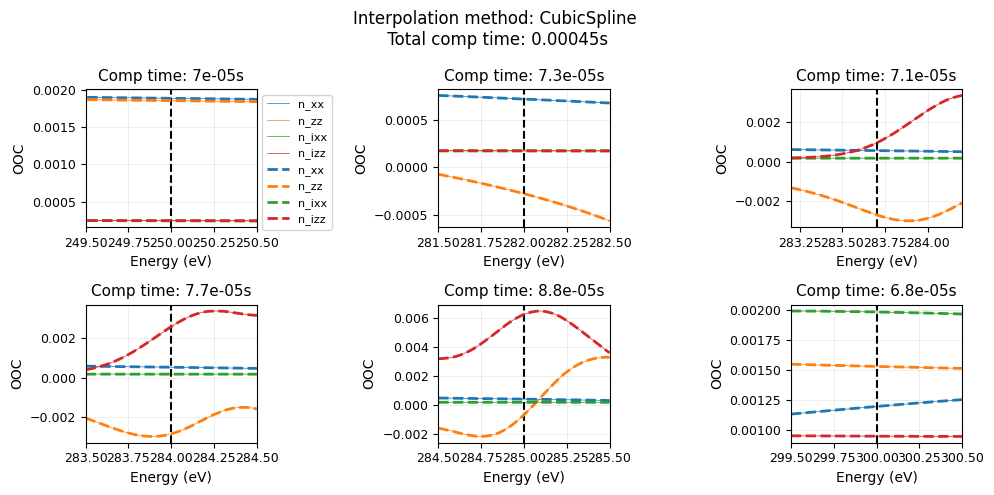

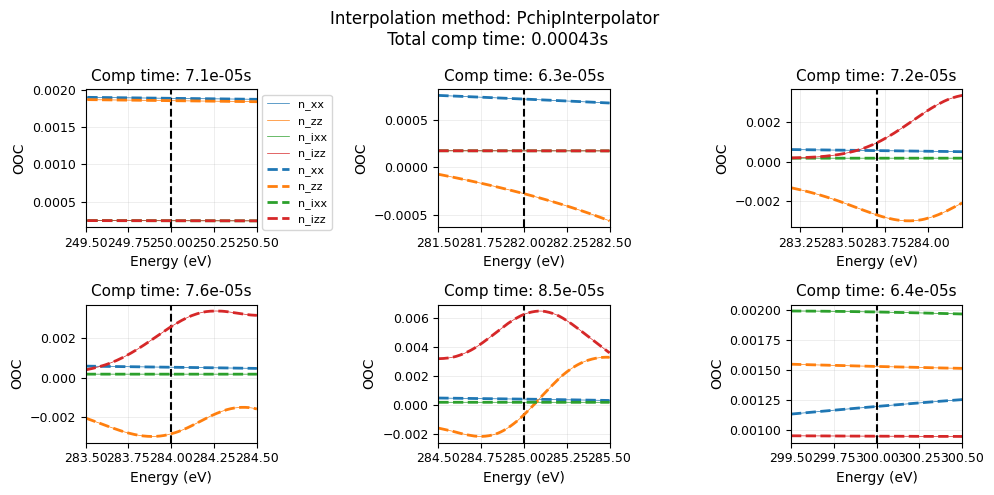

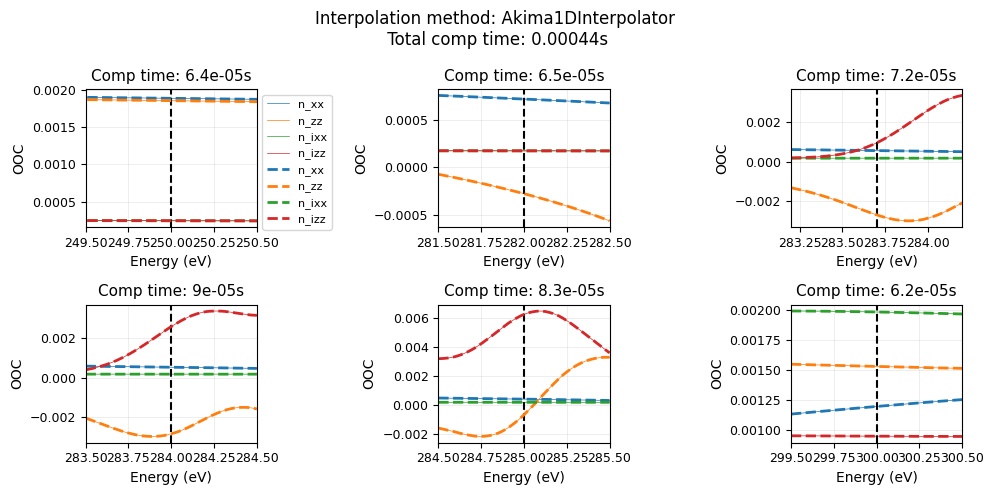

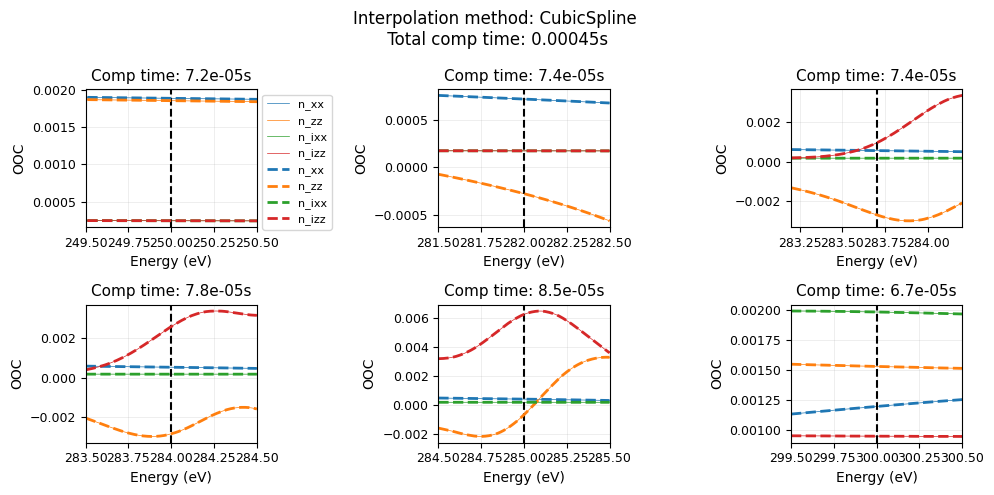

In [ ]:
# Try different interpolation methods over these regions to see
# what works best for this data

def interpolate_ooc(energy, component, scipy_method, **kwargs):
    """
    Wrapper to apply a general scipy.interpolate tool to (energy, component) data.

    Args:
        energy (array-like): x-values (energy).
        component (array-like): y-values (component values).
        scipy_method (str): Method name from scipy.interpolate
            (e.g., 'interp1d','CubicSpline', 'PchipInterpolator', etc.)
        **kwargs: Additional keyword arguments passed to
        the interpolation class/function.

    Returns:
        Callable: An interpolation function f(new_energy).

    Example:
        f_interp = interpolate_ooc(x, y, "interp1d", kind="cubic")
        y_new = f_interp(x_new)
    """
    import scipy.interpolate as interpolate

    interp_fn = getattr(interpolate, scipy_method)
    interpolator = interp_fn(energy, component, **kwargs)
    return interpolator

methods = [
    "interp1d",
    "CubicSpline",
    "PchipInterpolator",
    "Akima1DInterpolator",
    "CubicSpline",
]

kwargs = [
    {},
    {},
    {},
    {},
    {},
    {},
    {},
]

def plot_interpolation(ooc_df, test_energies, method):
    fig, _ax = plt.subplots(nrows=2, ncols=len(test_energies)//2, figsize=(10, 5))
    ax = _ax.flatten()
    total_comp_time = 0
    for i, energy in enumerate(test_energies):
        _masked = slice_range(ooc_df, "energy", energy, .5)
        _masked.plot(x="energy", ax=ax[i], lw=0.5, legend=False)
        ax[i].set_title(f"{energy} eV")
        ax[i].set_xlabel("Energy (eV)")
        ax[i].set_ylabel("OOC")
        ax[i].set_xlim(energy - 0.5, energy + 0.5)

        # add a vertical line at the energy
        ax[i].axvline(energy, color="k", linestyle="--")
        comp_time = []
        # Add interpolation for each component
        for j, component in enumerate(["n_xx", "n_zz", "n_ixx", "n_izz"]):
            f_interp = interpolate_ooc(
                _masked["energy"], _masked[component], method
            )
            start = perf_counter()
            # Get the interpolated values
            y_interp = f_interp(_masked["energy"])
            comp_time.append(perf_counter() - start)
            ax[i].plot(
                _masked["energy"],
                y_interp,
                label=component,
                ls="--",
                lw=2,
                color=f"C{j}"
            )
        # Add title as a comp time of the interpolated values
        ax[i].set_title(f"Comp time: {np.sum(comp_time):.2g}s")
        total_comp_time += np.sum(comp_time)
    fig.suptitle(f"Interpolation method: {method}\n Total comp time: {total_comp_time:.2g}s")
    ax[0].legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.tight_layout()

for method in methods:
    plot_interpolation(oocs, energyies, method)